In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

import math
import matplotlib.pyplot as plt

from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

In [38]:
base = "Universe_25"
params = ["c", "m", "n", "d", "k", "R"]
variations = [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10]

t_emp = np.array([0, 80, 315, 560, 736, 800, 900, 1000, 1280, 1350, 1480], dtype=int)
p_emp = np.array([8, 20, 620, 2200, 2056, 1800, 1500, 1250, 680, 320, 95], dtype=float)

In [40]:
BASE_DIR = Path.cwd()

OUT_FILE = BASE_DIR / "all_data.csv"

first = True

for p in params:
    for v in variations:
        sign = "m" if v < 0 else "p"
        val = f"{abs(v):02d}"
        fname = f"{base}_{p}_{sign}{val}.csv"
        fpath = BASE_DIR / fname

        df_temp = pd.read_csv(fpath, usecols=["t", "id", "population"])
        df_temp["param"] = p
        df_temp["variation"] = v

        df_temp.to_csv(
            OUT_FILE,
            mode="w" if first else "a",
            header=first,
            index=False
        )

        first = False

In [41]:
MIN_CLUSTER_SIZE = 30
MIN_SAMPLES = 15
CLUSTER_SELECTION_METHOD = "eom"

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUT_FILE = BASE_DIR / "clusters.csv"


def safe_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.allclose(x, x[0]):
        return 0.0
    return float(np.polyfit(x, y, 1)[0])


def extract_features(t, y):
    t = np.asarray(t, dtype=float)
    y = pd.Series(y).ffill().bfill().to_numpy(dtype=float)

    n = len(y)
    idx_peak = int(np.argmax(y))
    n_start = max(3, int(round(0.20 * n)))
    n_end = max(3, int(round(0.20 * n)))

    return [
        float(y[idx_peak]),
        float(t[idx_peak]),
        safe_slope(t[:n_start], y[:n_start]),
        float(np.trapezoid(y, t)),
        safe_slope(t[-n_end:], y[-n_end:]),
        float(y[-1])
    ]


def build_feature_matrix(t, sims):
    return np.asarray([extract_features(t, sim) for sim in sims], dtype=float)


first = True

for p in params:
    for v in variations:
        sign = "m" if v < 0 else "p"
        val = f"{abs(v):02d}"
        fname = f"{base}_{p}_{sign}{val}.csv"
        fpath = BASE_DIR / fname

        df_temp = pd.read_csv(fpath, usecols=["t", "id", "population"])

        pivot = df_temp.pivot(index="t", columns="id", values="population").sort_index()

        t = pivot.index.to_numpy(dtype=float)
        sims = pivot.to_numpy(dtype=float).T
        sims = pd.DataFrame(sims).ffill(axis=1).bfill(axis=1).to_numpy(dtype=float)

        X = build_feature_matrix(t, sims)

        # QUI la fix
        scaler = StandardScaler(copy=True)
        X = scaler.fit_transform(X)

        labels = HDBSCAN(
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES,
            cluster_selection_method=CLUSTER_SELECTION_METHOD,
            allow_single_cluster=False
        ).fit_predict(X)

        out = pd.DataFrame({
            "param": p,
            "variation": v,
            "id": pivot.columns.to_numpy(),
            "cluster": labels
        })

        out.to_csv(
            OUT_FILE,
            mode="w" if first else "a",
            header=first,
            index=False
        )

        first = False

C:\Users\FedericoCarucci\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\FedericoCarucci\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\FedericoCarucci\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence th

In [ ]:
# ===== INPUT =====
INPUT_FILE = Path("modal_cluster_mean_timeseries.csv")

df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.strip()

# ===== DATI EMPIRICI =====
t_emp = np.array([0, 80, 315, 560, 736, 800, 900, 1000, 1280, 1350, 1480], dtype=float)
p_emp = np.array([8, 20, 620, 2200, 2056, 1800, 1500, 1250, 680, 320, 95], dtype=float)

# ===== NRMSE (QUI è il calcolo) =====
def nrmse_on_points_range(t_sim, curve, t_emp, p_emp):
    p_sim = np.interp(t_emp, t_sim, curve)
    rmse = np.sqrt(np.mean((p_sim - p_emp) ** 2))
    return rmse / (np.max(p_emp) - np.min(p_emp))


# ===== RICALCOLO NRMSE (se vuoi verificarlo) =====
check_rows = []

for (param, variation), g in df.groupby(["parameter", "variation"]):
    g = g.sort_values("t")

    t = g["t"].to_numpy(dtype=float)
    mean_ts = g["mean_population"].to_numpy(dtype=float)

    nrmse = nrmse_on_points_range(t, mean_ts, t_emp, p_emp)

    check_rows.append({
        "parameter": param,
        "variation": variation,
        "NRMSE_recomputed": nrmse
    })

check_df = pd.DataFrame(check_rows)
print(check_df.head())

  parameter variation  NRMSE_recomputed
0         c       m02          0.046806
1         c       m04          0.051536
2         c       m06          0.055756
3         c       m08          0.068572
4         c       m10          0.077930


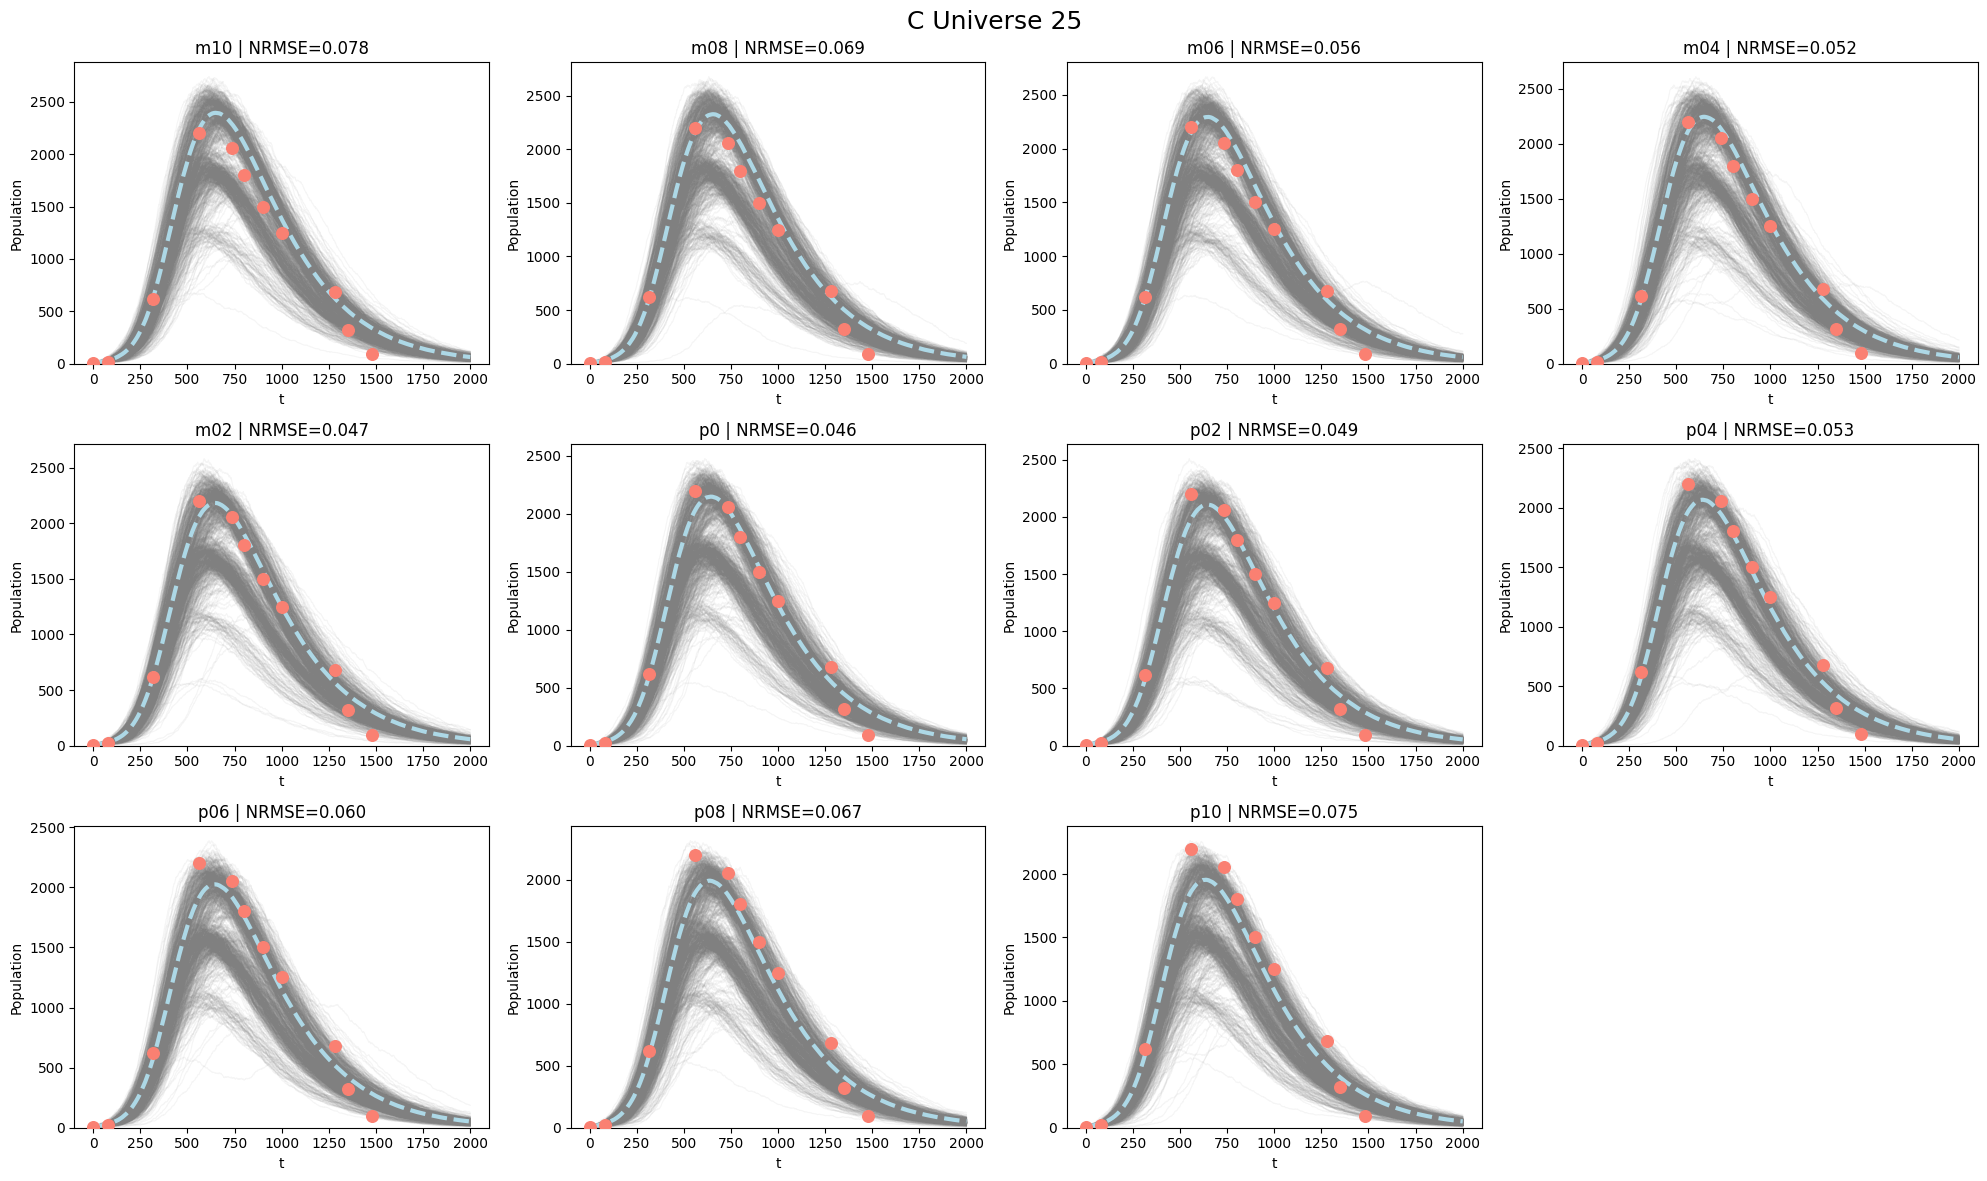

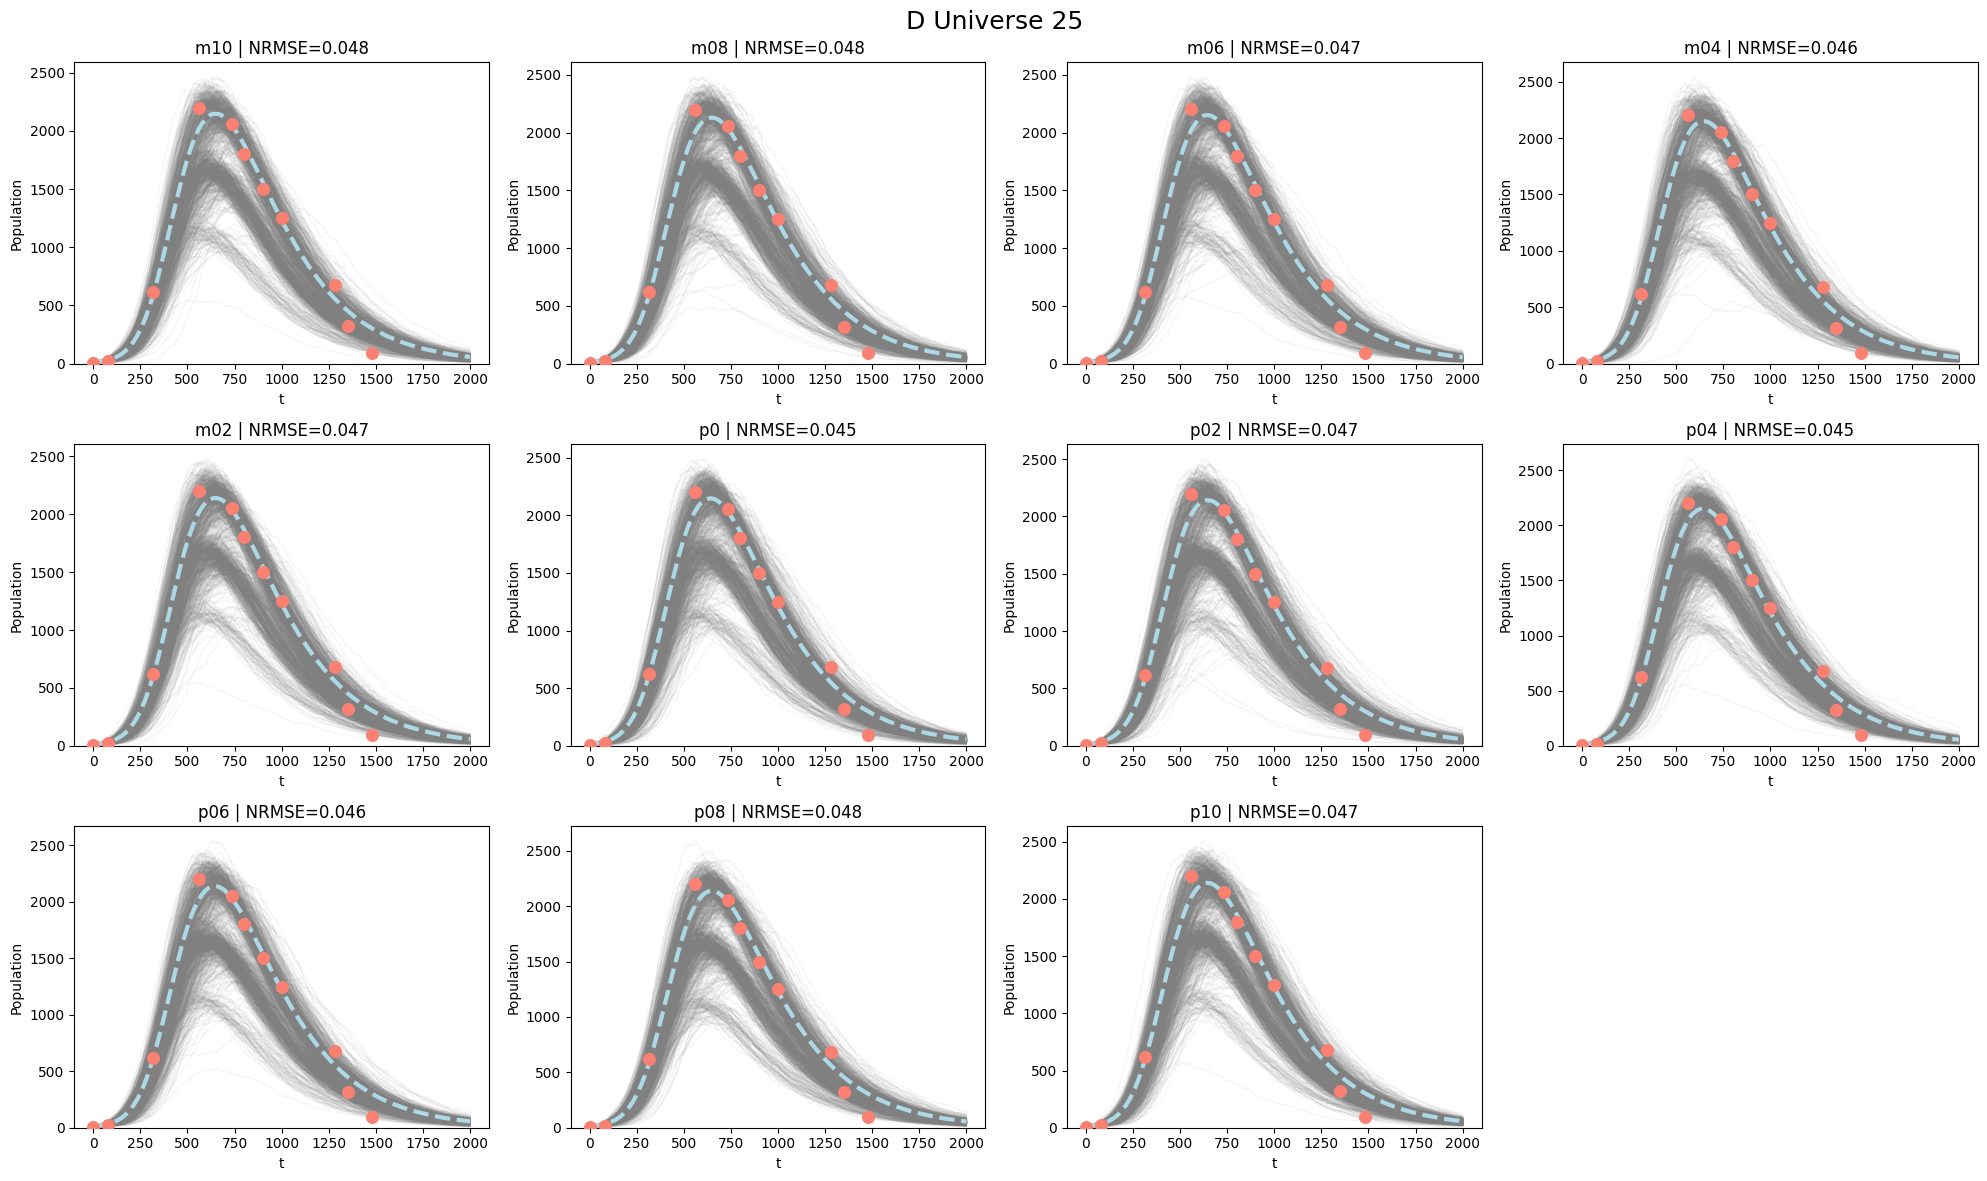

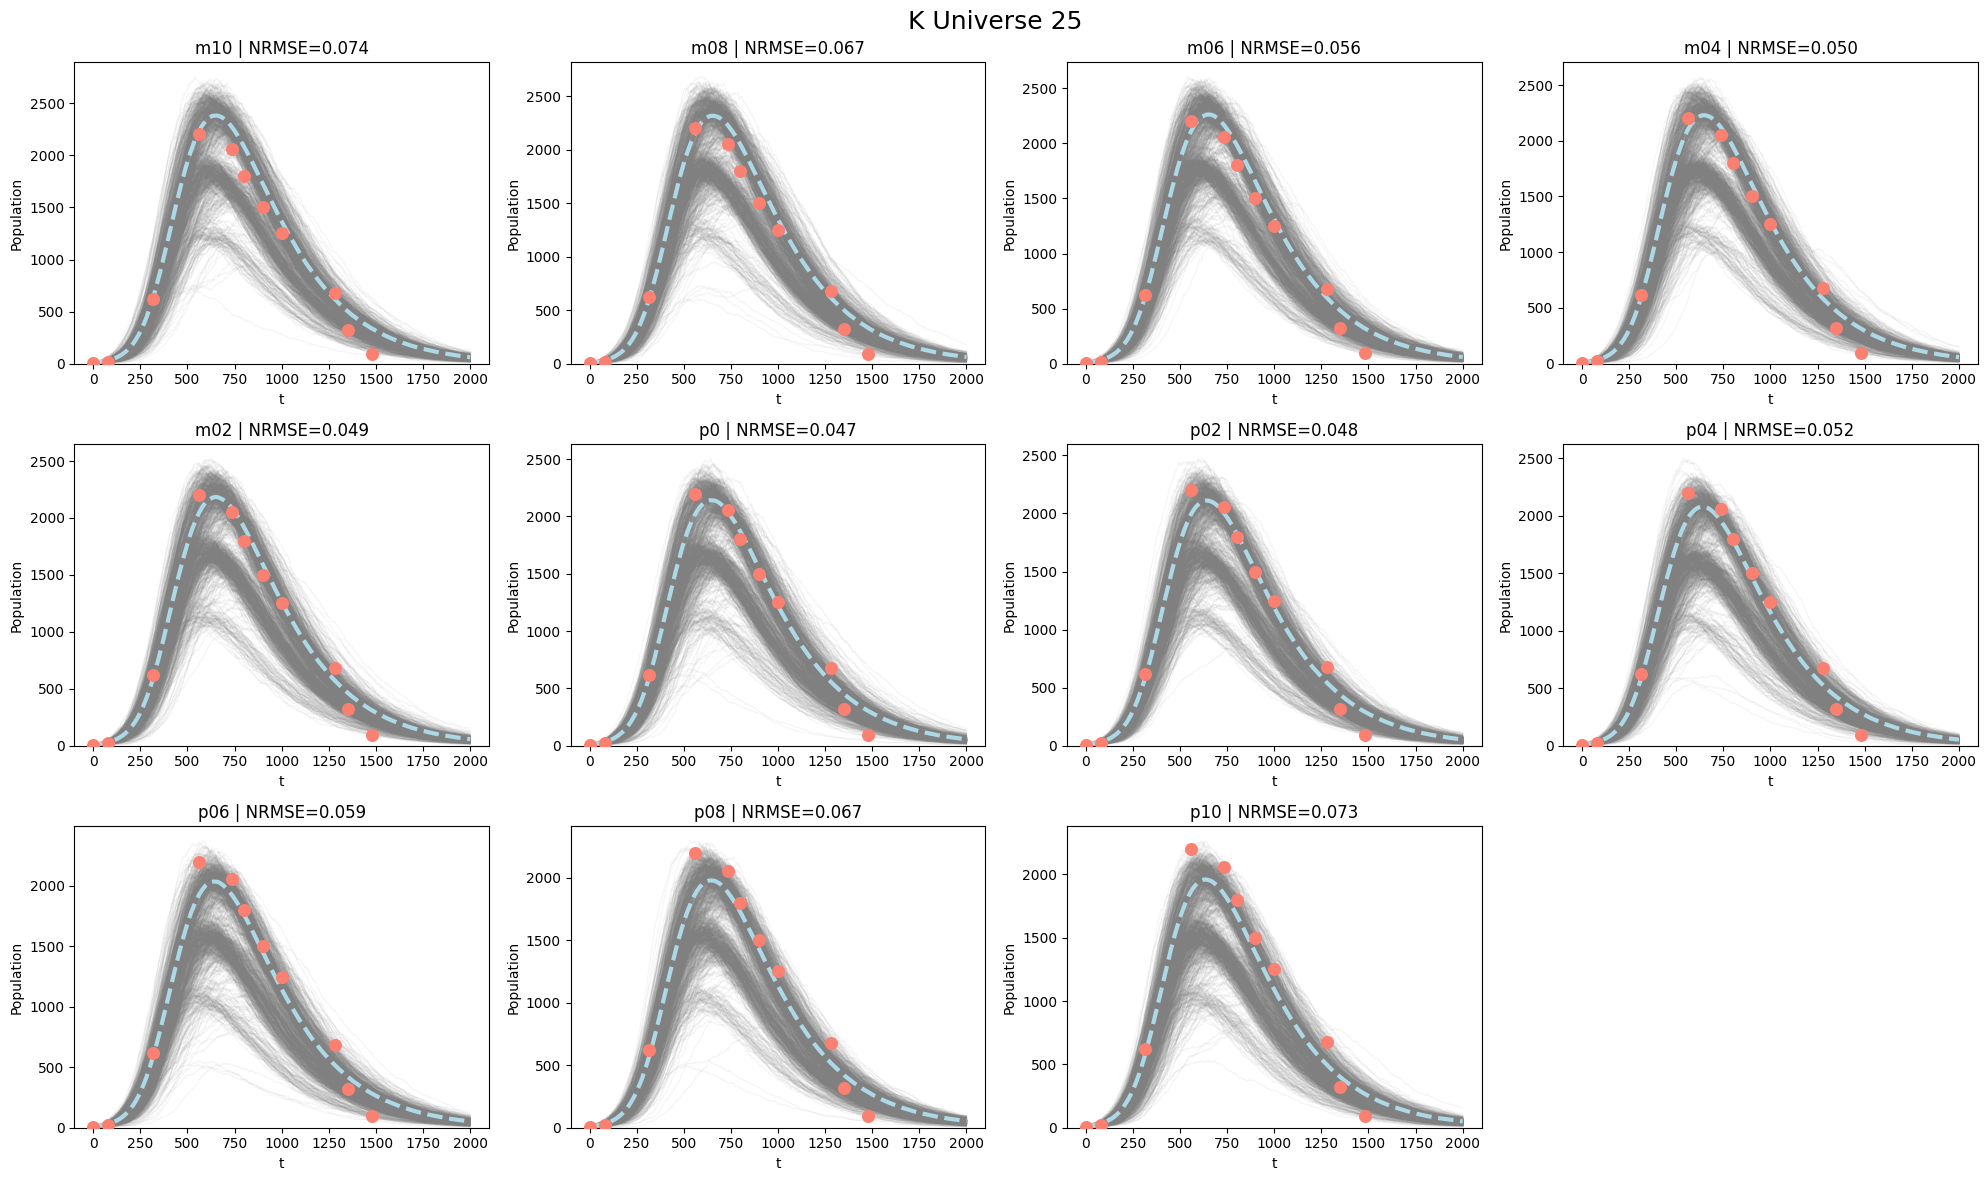

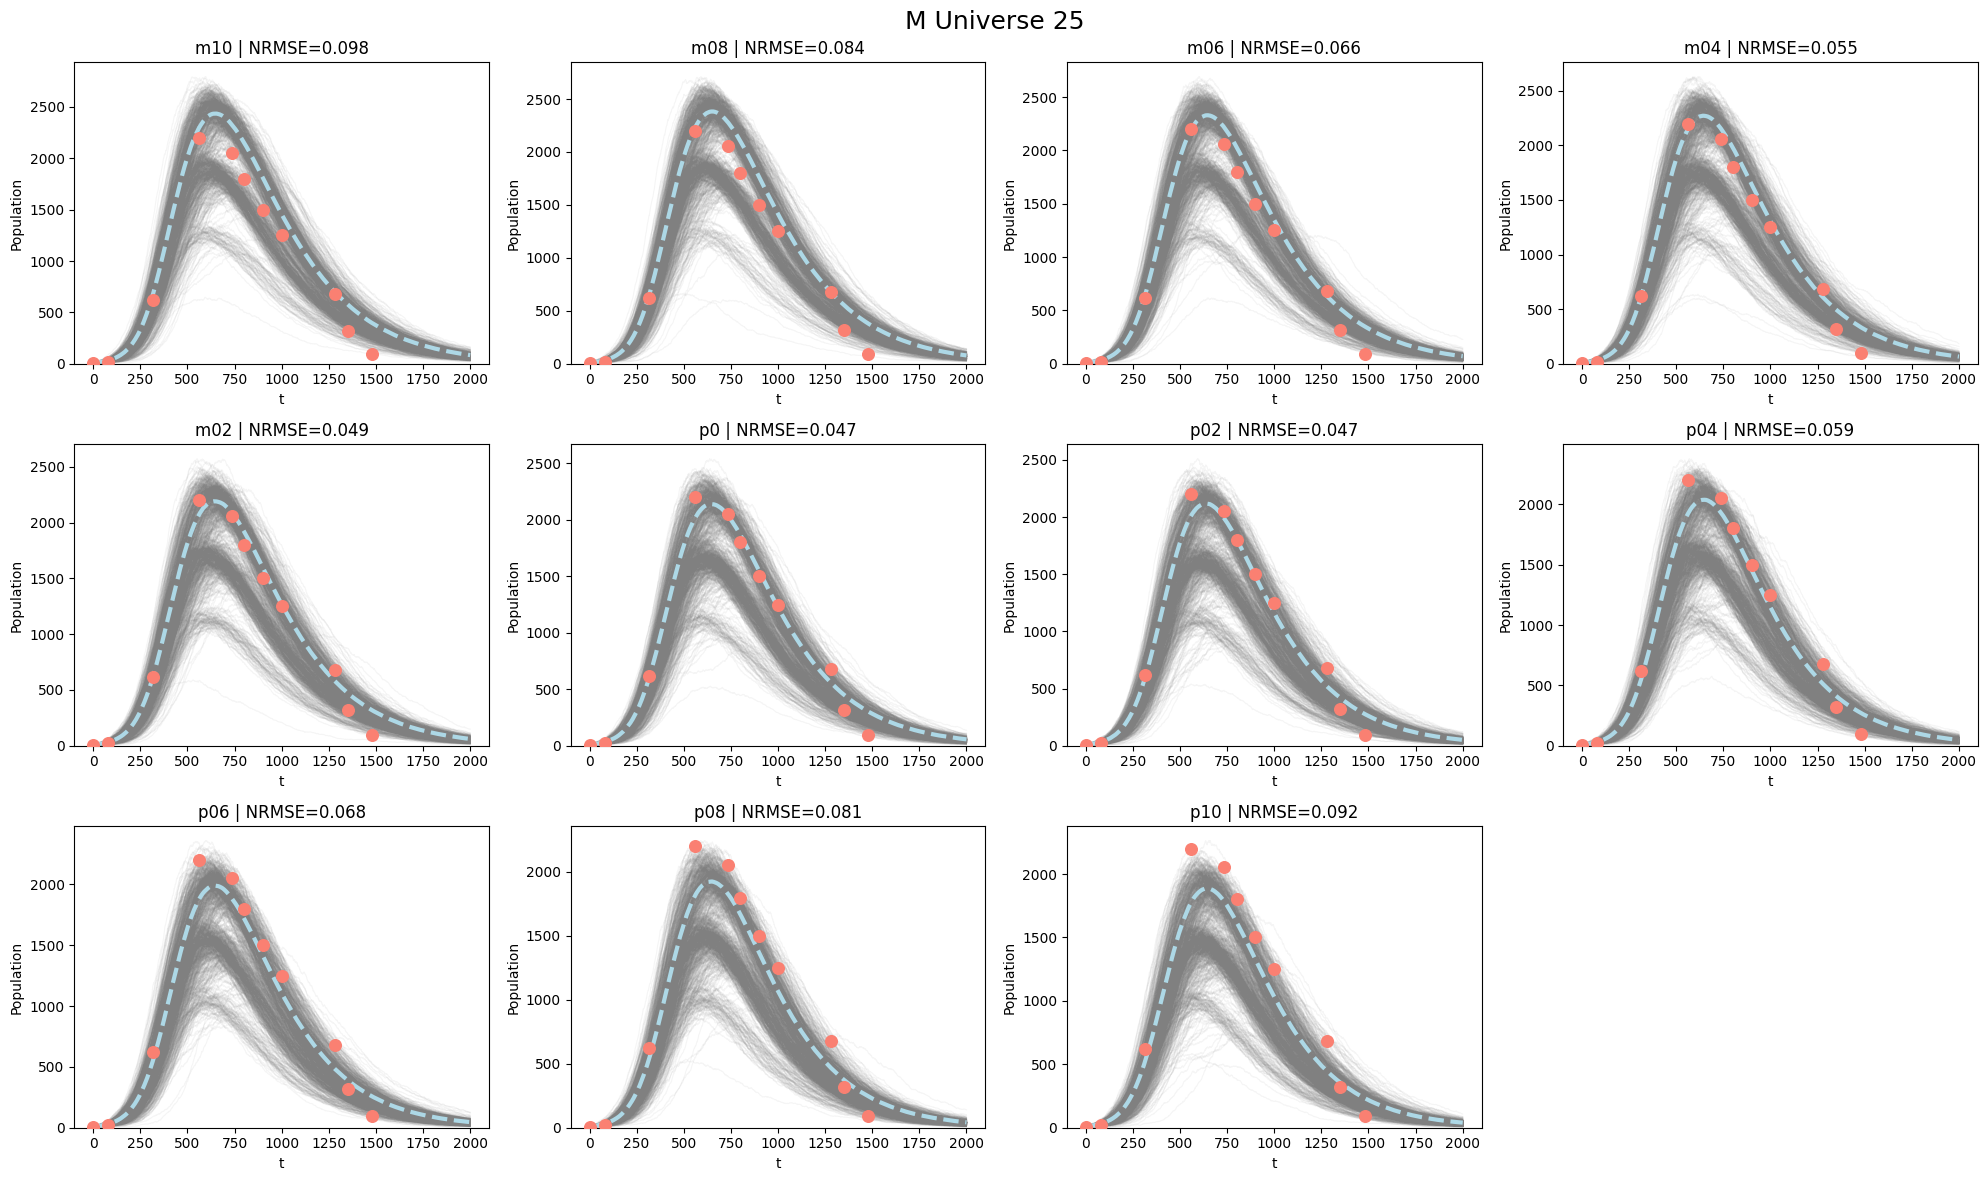

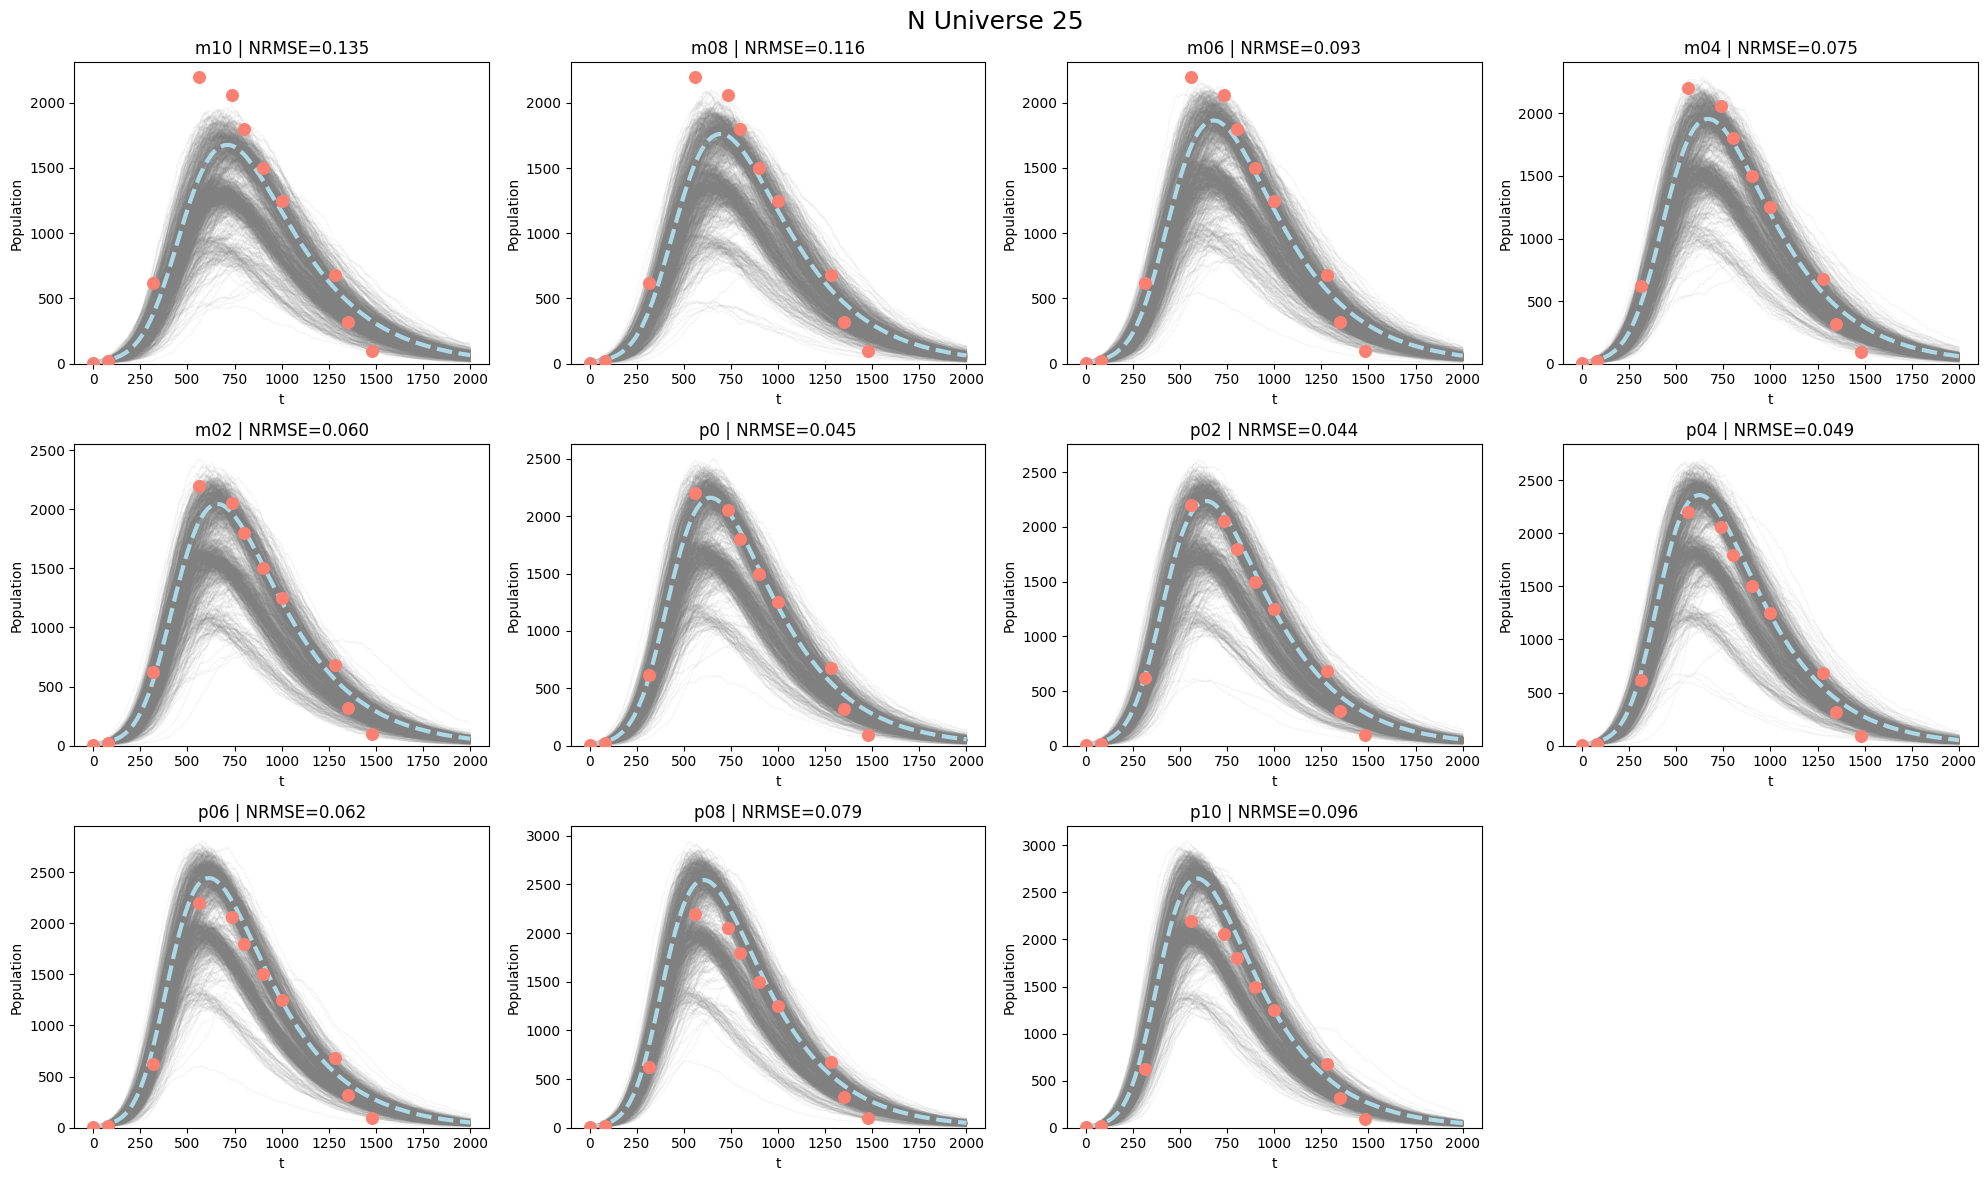

In [ ]:

for param in sorted(df["param"].unique()):
    data = []

    for variation, g in df[df["param"] == param].groupby("variation"):
        pivot = g.pivot(index="t", columns="id", values="population").sort_index()

        t = pivot.index.to_numpy(dtype=float)
        sims = pivot.to_numpy(dtype=float)

        labs = clusters_df[
            (clusters_df["param"] == param) &
            (clusters_df["variation"] == variation)
        ]

        counts = labs[labs["cluster"] != -1]["cluster"].value_counts()

        if len(counts) == 0:
            modal_ids = labs["id"].to_numpy()
        else:
            modal_cluster = counts.idxmax()
            modal_ids = labs.loc[labs["cluster"] == modal_cluster, "id"].to_numpy()

        mean_ts = pivot[modal_ids].mean(axis=1).to_numpy(dtype=float)
        nrmse = nrmse_on_points_range(t, mean_ts, t_emp, p_emp)

        data.append((variation, t, sims, mean_ts, nrmse))

    data.sort(key=lambda x: x[0])

    n = len(data)
    n_cols = 4
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (variation, t, sims, mean_ts, nrmse) in zip(axes, data):
        for i in range(sims.shape[1]):
            ax.plot(t, sims[:, i], color="grey", alpha=0.08, linewidth=0.8)

        ax.plot(t, mean_ts, color="lightblue", linestyle="--", linewidth=3)

        ax.scatter(t_emp, p_emp, color="salmon", s=70, zorder=5)

        ax.set_title(f"{var_label(variation)} | NRMSE={nrmse:.3f}")
        ax.set_xlabel("t")
        ax.set_ylabel("Population")
        ax.set_ylim(bottom=0)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"{param.upper()} Universe 25", fontsize=18)
    plt.tight_layout()
    plt.show()